In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('C:/Users/28cha/Desktop/New folder/Learn-Numpy-and-Pandas-and-Matplotlib/mnist_train.csv')
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data = np.array(df)
np.random.shuffle(data)
X_train = data[:, 1:].T
Y_train = data[:, 0].T

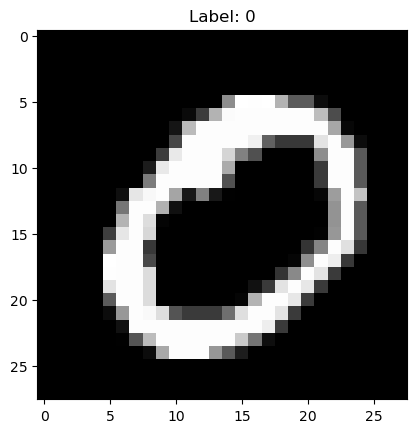

In [6]:
index = 0
pixels = X_train[:, index].reshape(28, 28)
plt.imshow(pixels, cmap='gray')
label = Y_train[index]
plt.title(f'Label: {int(label)}')
plt.show()

In [5]:
def initialize_parameters():
    w1 = np.random.rand(10,784) - 0.5 #10x784
    b1 = np.random.rand(10,1) - 0.5 #10x1
    w2 = np.random.rand(10,10) - 0.5 #10x10
    b2 = np.random.rand(10,1) - 0.5 #10x1
    return w1, b1, w2, b2

def ReLU(X):
    return np.maximum(X,0)

def softmax(X):
    e_X = np.exp(X - np.max(X, axis=0, keepdims=True))
    return e_X / e_X.sum(axis=0, keepdims=True)

def forward_propagation(w1, b1, w2, b2, X):
    z1 = w1.dot(X) + b1 # 10x1
    a1 = ReLU(z1) #10x1
    z2 = w2.dot(a1) + b2 #10x1
    a2 = softmax(z2) #10x1
    return z1, a1, z2, a2

def one_hot_encoding(Y):
    Y = Y.astype(int)
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_propagation(w2, z1, a1, a2, X, Y, m):
    one_hot_Y = one_hot_encoding(Y) #10x1
    dw2 = (1/m) * (a2 - one_hot_Y) @ a1.T #10x10
    db2 = (1/m) * np.sum(a2 - one_hot_Y, axis=1, keepdims=True) #10x1
    dw1 = (1/m) * (w2.T @ (a2 - one_hot_Y) * (z1>0)) @ X.T #10x784
    db1 = (1/m) * np.sum(w2.T @ (a2 - one_hot_Y) * (z1>0), axis=1, keepdims=True) # 10x1
    return dw2, db2, dw1, db1
    

def update_parameters(w2, b2, w1, b1, dw2, db2, dw1, db1, eta):
  w2 -= eta * dw2
  b2 -= eta * db2
  w1 -= eta * dw1
  b1 -= eta * db1
  return w2, b2, w1, b1

def get_predictions(a2):
  return np.argmax(a2, 0)

def get_accuracy(predictions, Y):
  return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, eta, batch_size):
    X = X / 255.0
    W1, B1, W2, B2 = initialize_parameters()
    n_examples = X.shape[1]

    for i in range(iterations + 1):
        permutation = np.random.permutation(n_examples)
        X_shuffled = X[:, permutation]
        Y_shuffled = Y[permutation]
        for j in range(0, n_examples, batch_size):
            X_batch = X_shuffled[:, j:j+batch_size]
            Y_batch = Y_shuffled[j:j+batch_size]
            Z1, A1, Z2, A2 = forward_propagation(W1, B1, W2, B2, X_batch)
            Dw2, Db2, Dw1, Db1 = backward_propagation(W2, Z1, A1, A2, X_batch, Y_batch, batch_size)
            W2, B2, W1, B1 = update_parameters(W2, B2, W1, B1, Dw2, Db2, Dw1, Db1, eta)
        if i % 20 == 0:
            _, _, _, A2_test = forward_propagation(W1, B1, W2, B2, X)
            print("Iteration: ", i)
            predictions = get_predictions(A2_test)
            print("Accuracy", get_accuracy(predictions, Y))
    
    return W2, B2, W1, B1

In [7]:
W2, B2, W1, B1 = gradient_descent(X_train, Y_train, 100, 0.1, 100)

Iteration:  0
Accuracy 0.8611666666666666
Iteration:  20
Accuracy 0.94035
Iteration:  40
Accuracy 0.9469666666666666
Iteration:  60
Accuracy 0.9517333333333333
Iteration:  80
Accuracy 0.9549833333333333
Iteration:  100
Accuracy 0.9554


In [8]:
test = pd.read_csv('C:/Users/28cha/Desktop/New folder/Learn-Numpy-and-Pandas-and-Matplotlib/mnist_test.csv')
test.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
test_data = np.array(test)
X_test = test_data[:, 1:].T
Y_test = test_data[:, 0].T

_, _, _, A2_test = forward_propagation(W1, B1, W2, B2, X_test)
test_predictions = get_predictions(A2_test)

accuracy = get_accuracy(test_predictions, Y_test)
print(accuracy)

0.9022


In [10]:
errors = test_predictions != Y_test

total_wrong = 0
total_wrong += np.sum(errors)

print(f"Total errors: {total_wrong} out of {len(Y_test)}")

Total errors: 978 out of 10000


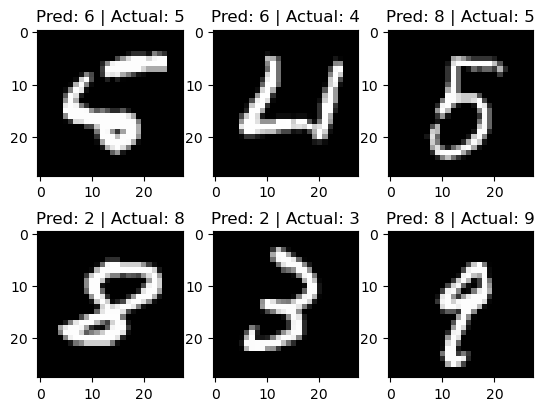

In [11]:
idx = np.where(errors == 1)[0]
for i in range(min(6, len(idx))):
    img = X_test[:, idx[i]].reshape(28, 28)
    predicted_label = test_predictions[idx[i]]
    actual_label = Y_test[idx[i]]
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {predicted_label} | Actual: {int(actual_label)}")

plt.show()